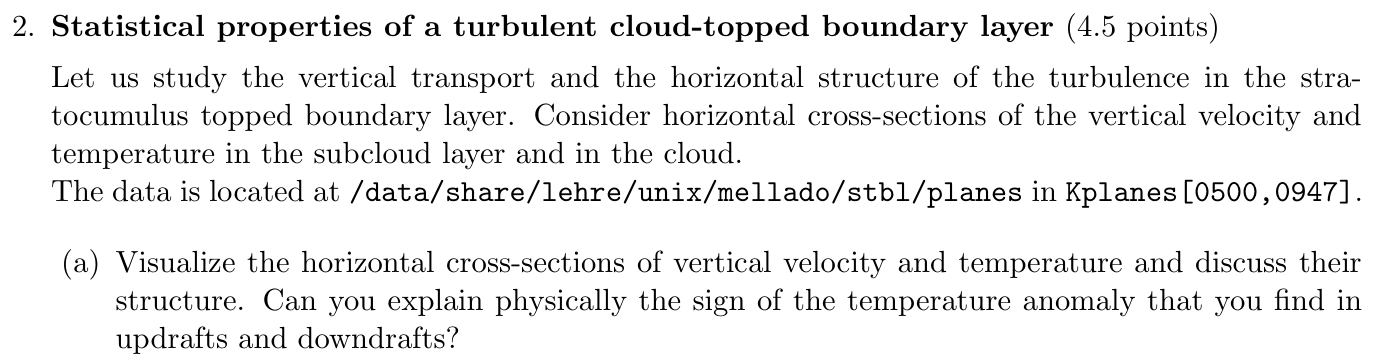

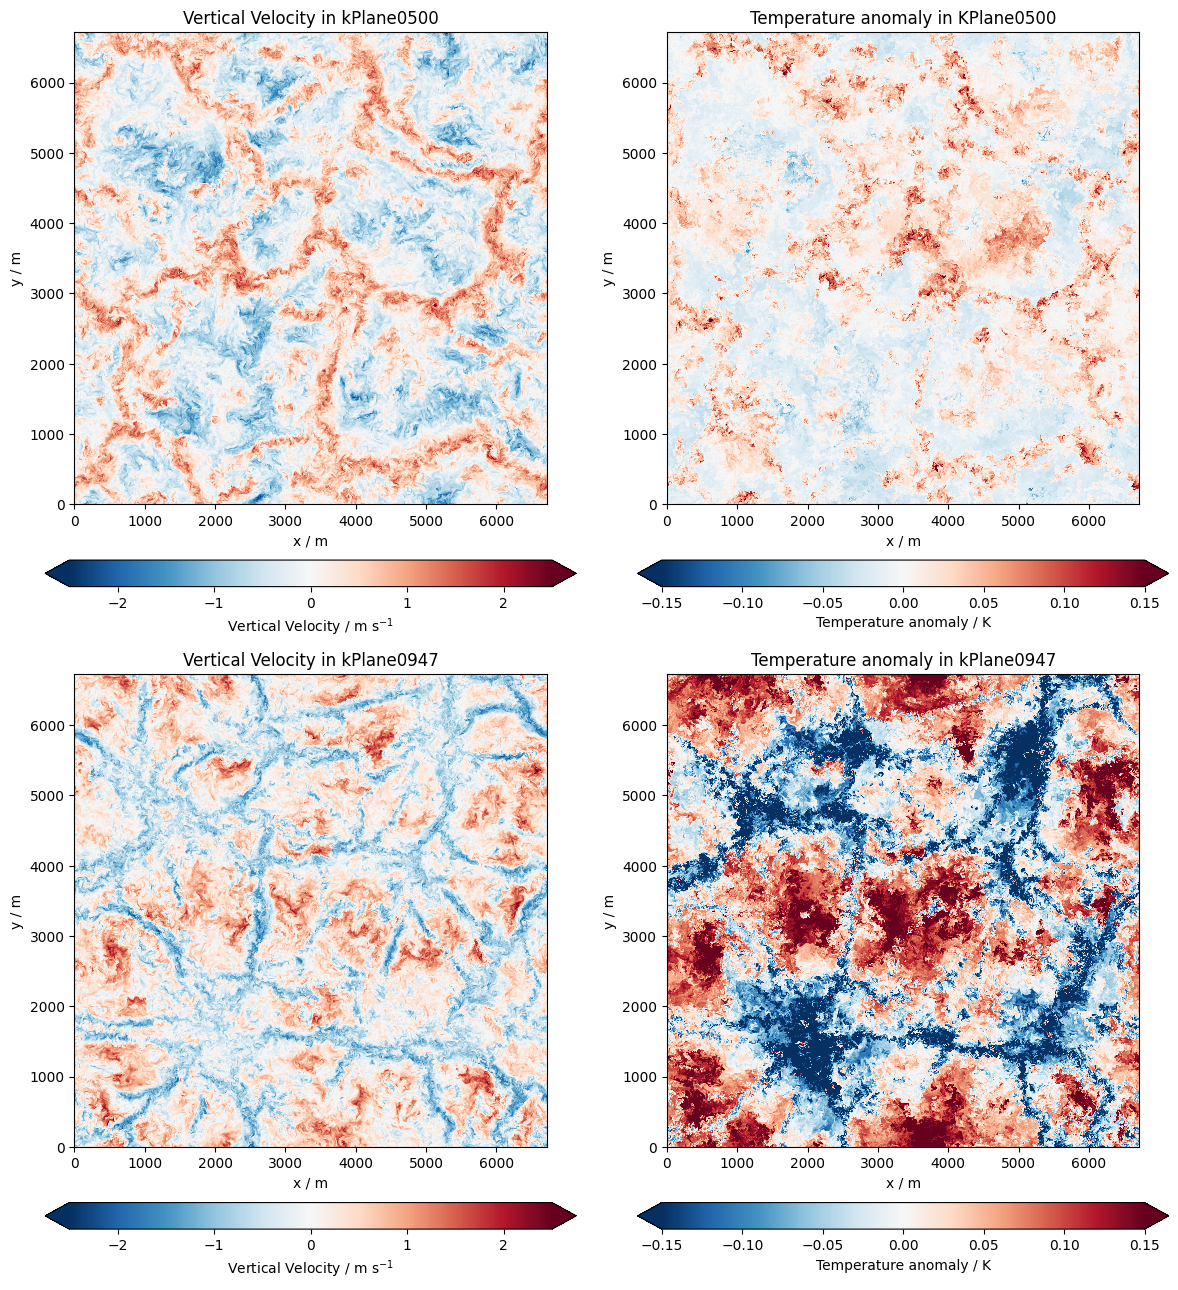

In [50]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


# Load datasets.
path1 = Path("VerticalVelocity.nc")
path2 = Path("Temperature160000.nc")
path3 = Path("VerticalVelocity1.nc")
path4 = Path("Temperature1600001.nc")

ds1 = xr.open_dataset(path1)
ds2 = xr.open_dataset(path2)
ds3 = xr.open_dataset(path3)
ds4 = xr.open_dataset(path4)

# Select variables.
vertical_velocity = ds1['w'].isel(t=0, z=0)
temperature = ds2['T'].isel(t=0, z=0)
mean_temp = np.mean(temperature)
temp_anom = temperature - mean_temp

vertical_velocity2 = ds3['w'].isel(t=0, z=0)
temperature2 = ds4['T'].isel(t=0, z=0)
mean_temp2 = np.mean(temperature2)
temp_anom2 = temperature2 - mean_temp2

X, Y = np.meshgrid(ds1.x, ds1.y)


# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 13))
ax1, ax2, ax3, ax4 = axes.flatten()

# ax1: Vertical Velocity plot in KPlane0500.
ax1.set_title('Vertical Velocity in kPlane0500')

w_plot = ax1.pcolormesh(
    X,
    Y,
    vertical_velocity,
    cmap='RdBu_r',
    vmin=-2.5,
    vmax=2.5
)

fig.colorbar(
    w_plot,
    ax=ax1,
    orientation='horizontal',
    label=r"Vertical Velocity / m s$^{-1}$",
    extend='both',
    fraction=0.05,
    pad=0.1
)

# ax2: Temperature anomaly plot in kPlane0500.
ax2.set_title('Temperature anomaly in KPlane0500')

T_plot = ax2.pcolormesh(
    X,
    Y,
    temp_anom,
    cmap='RdBu_r',
    vmin=-0.15,
    vmax=0.15
)

fig.colorbar(
    T_plot,
    ax=ax2,
    orientation='horizontal',
    label="Temperature anomaly / K",
    extend='both',
    fraction=0.05,
    pad=0.1
)

# ax3: Vertical Velocity plot in KPlane0947.
ax3.set_title('Vertical Velocity in kPlane0947')

w_plot2 = ax3.pcolormesh(
    X,
    Y,
    vertical_velocity2,
    cmap='RdBu_r',
    vmin=-2.5,
    vmax=2.5
)

fig.colorbar(
    w_plot,
    ax=ax3,
    orientation='horizontal',
    label=r"Vertical Velocity / m s$^{-1}$",
    extend='both',
    fraction=0.05,
    pad=0.1
)

# ax4: Temperature anomaly plot in kPlane0947.
ax4.set_title('Temperature anomaly in kPlane0947')

T_plot2 = ax4.pcolormesh(
    X,
    Y,
    temp_anom2,
    cmap='RdBu_r',
    vmin=-0.15,
    vmax=0.15
)

fig.colorbar(
    T_plot2,
    ax=ax4,
    orientation='horizontal',
    label="Temperature anomaly / K",
    extend='both',
    fraction=0.05,
    pad=0.1
)

for ax in axes.flatten():
    ax.set_aspect('equal')
    ax.set_xlabel('x / m')
    ax.set_ylabel('y / m')


plt.tight_layout()
plt.show()

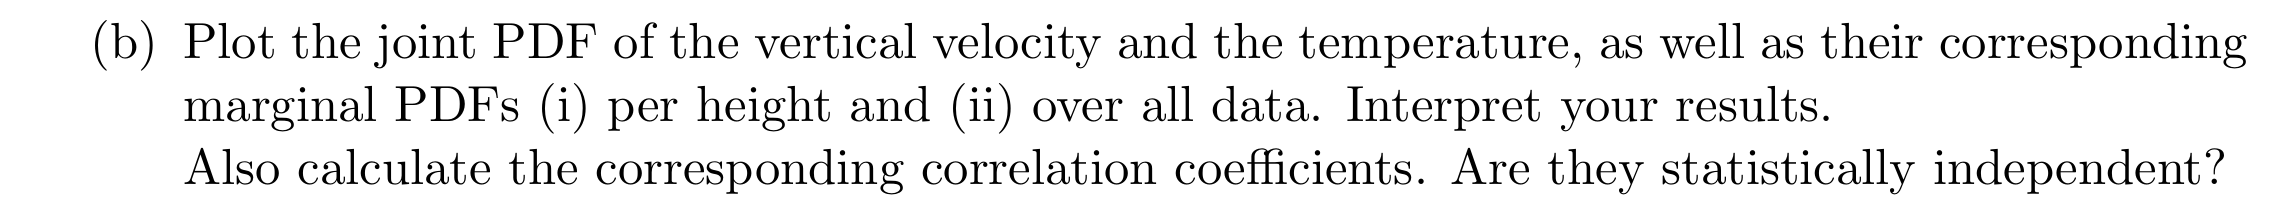

## kPlane0500

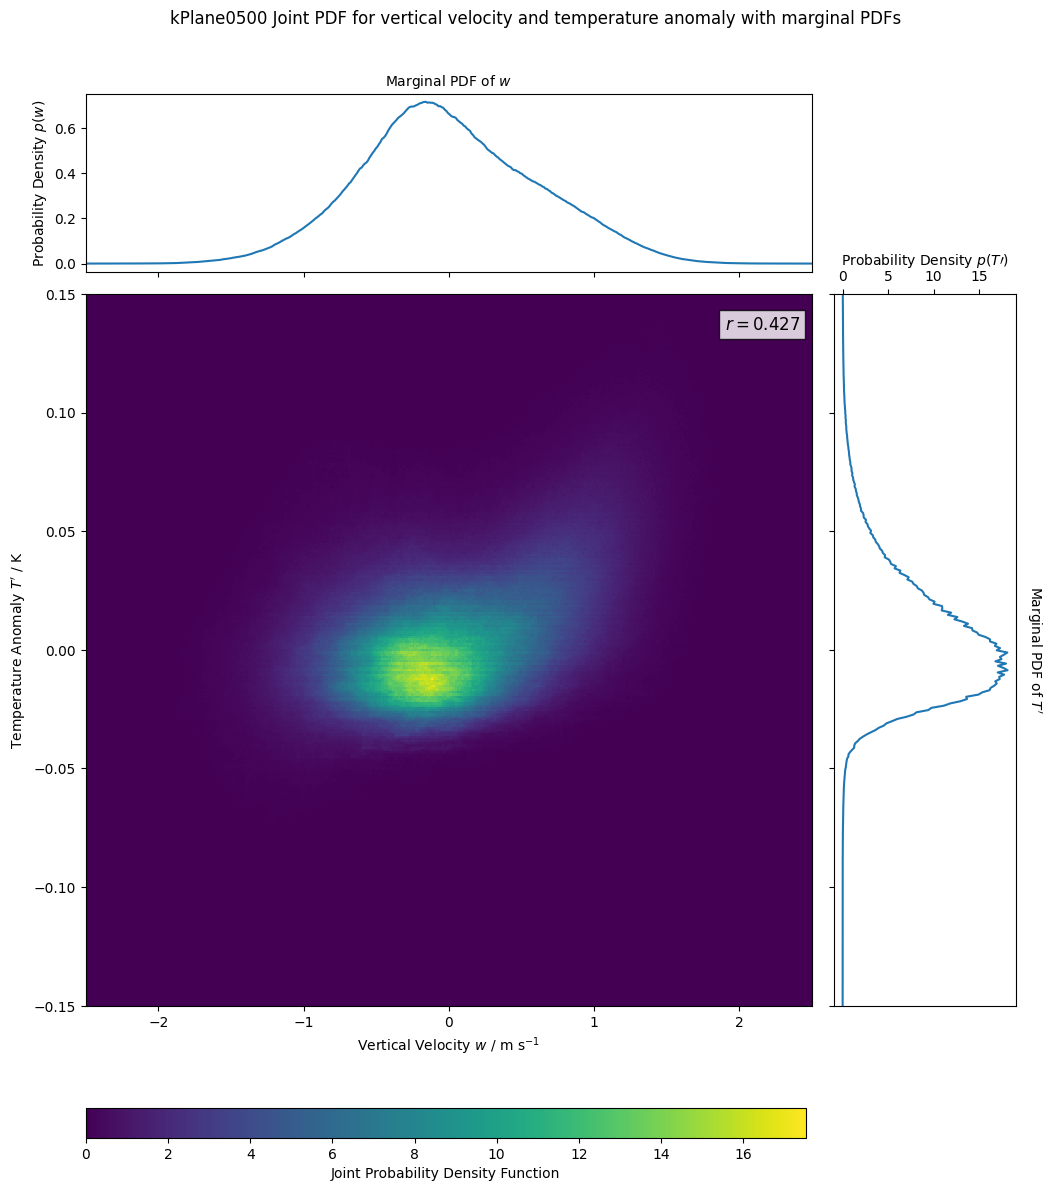

RMS vertical velocity mean: 0.00000 m/s
RMS temperature mean: 0.006 K
RMS vertical velocity fluctuation: 0.604 m/s
RMS temperature fluctuation: 0.027 K
Smallest resolved velocity fluctuation: 0.01082 m/s
Smallest resolved temperature fluctuation: 0.00093 K


In [138]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten arrays
w_500 = vertical_velocity.values.ravel()
t_500 = temp_anom.values.ravel()

# Remove NaNs if present
mask = np.isfinite(w_500) & np.isfinite(t_500)

w_500 = w_500[mask]
t_500 = t_500[mask]

# Pearson correlation coefficient
r = np.corrcoef(w_500, t_500)[0, 1]

# Joint histogram
pdf_500, w500_edges, T500_edges = np.histogram2d(
    w_500,
    t_500,
    bins=500,
    density=True
)

# Marginals
w500_pdf, w500_bins = np.histogram(
    w_500,
    bins=500,
    density=True
)

T500_pdf, T500_bins = np.histogram(
    t_500,
    bins=500,
    density=True
)

# Bin centers
w500_centers = 0.5 * (w500_bins[:-1] + w500_bins[1:])
T500_centers = 0.5 * (T500_bins[:-1] + T500_bins[1:])

# Figure layout
fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[4, 1],
    height_ratios=[1, 4],
    hspace=0.05,
    wspace=0.05
)

ax_joint = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint PDF
pcm = ax_joint.pcolormesh(
    w500_edges,
    T500_edges,
    pdf_500.T,
    shading='auto',
    cmap='viridis'
)

# Correlation coefficient annotation
ax_joint.text(
    0.88,
    0.97,
    rf'$r = {r:.3f}$',
    transform=ax_joint.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        alpha=0.8
    )
)

# Marginals
ax_top.plot(w500_centers, w500_pdf)
ax_right.plot(T500_pdf, T500_centers)

# Labels and limits
ax_joint.set_xlabel(r'Vertical Velocity $w$ / m s$^{-1}$')
ax_joint.set_ylabel(r'Temperature Anomaly $T^\prime$ / K')
ax_joint.set_xlim(-2.5, 2.5)
ax_joint.set_ylim(-0.15, 0.15)

ax_top.set_ylabel(r'Probability Density $p(w)$')
ax_top.set_title(r'Marginal PDF of $w$', fontsize=10)

ax_right.set_xlabel(r'Probability Density $p(T\prime)$')
ax_right.set_ylabel(r'Marginal PDF of $T^\prime$', fontsize=10, rotation=270, labelpad=20)
ax_right.yaxis.set_label_position('right')
ax_right.xaxis.set_label_position('top')

# Hide redundant labels
ax_top.tick_params(labelbottom=False)
ax_right.tick_params(labelleft=False, labeltop=True, top=True, bottom=False, labelbottom=False)

# Colorbar
fig.subplots_adjust(bottom=0.12)

# Manual colorbar axis
cax = fig.add_axes([0.125, 0.01, 0.60, 0.025])

# Horizontal colorbar
cbar = fig.colorbar(
    pcm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label('Joint Probability Density Function')

fig.suptitle("kPlane0500 Joint PDF for vertical velocity and temperature anomaly with marginal PDFs", y=0.95)

plt.show()


# Means
w_mean = np.mean(w_500)
t_mean = np.mean(t_500)

print(f"RMS vertical velocity mean: {w_mean:.3f} m/s")
print(f"RMS temperature mean: {t_mean:.3f} K")

# RMS fluctuations
w_rms = np.std(w_500)
T_rms = np.std(t_500)

print(f"RMS vertical velocity fluctuation: {w_rms:.3f} m/s")
print(f"RMS temperature fluctuation: {T_rms:.3f} K")

# Smallest resolved fluctuation scales
dw_small = w500_bins[1] - w500_bins[0]
dT_small = T500_bins[1] - T500_bins[0]

print(f"Smallest resolved velocity fluctuation: {dw_small:.5f} m/s")
print(f"Smallest resolved temperature fluctuation: {dT_small:.5f} K")

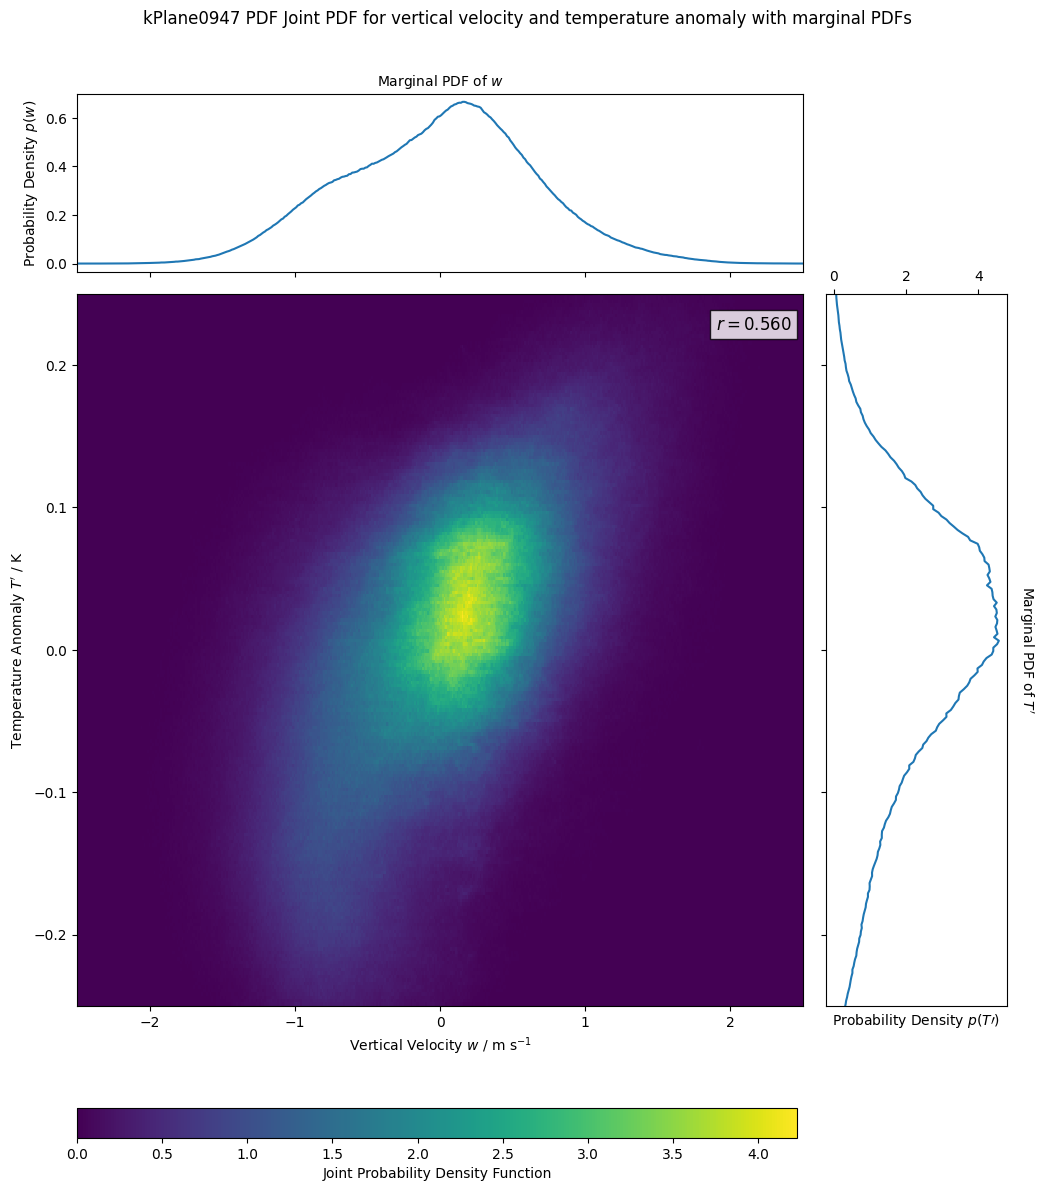

RMS vertical velocity mean: -0.000 m/s
RMS temperature mean: 0.001 K
RMS vertical velocity fluctuation: 0.649 m/s
RMS temperature fluctuation: 0.097 K
Smallest resolved velocity fluctuation: 0.01135 m/s
Smallest resolved temperature fluctuation: 0.00243 K


In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten arrays
w_500 = vertical_velocity2.values.ravel()
t_500 = temp_anom2.values.ravel()

# Remove NaNs if present
mask = np.isfinite(w_500) & np.isfinite(t_500)

w_500 = w_500[mask]
t_500 = t_500[mask]

# Pearson correlation coefficient
r = np.corrcoef(w_500, t_500)[0, 1]

# Joint histogram
pdf_500, w500_edges, T500_edges = np.histogram2d(
    w_500,
    t_500,
    bins=500,
    density=True
)

# Marginals
w500_pdf, w500_bins = np.histogram(
    w_500,
    bins=500,
    density=True
)

T500_pdf, T500_bins = np.histogram(
    t_500,
    bins=500,
    density=True
)

# Bin centers
w500_centers = 0.5 * (w500_bins[:-1] + w500_bins[1:])
T500_centers = 0.5 * (T500_bins[:-1] + T500_bins[1:])


# Figure layout
fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[4, 1],
    height_ratios=[1, 4],
    hspace=0.05,
    wspace=0.05
)

ax_joint = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint PDF
pcm = ax_joint.pcolormesh(
    w500_edges,
    T500_edges,
    pdf_500.T,
    shading='auto',
    cmap='viridis'
)

# Correlation coefficient annotation
ax_joint.text(
    0.88,
    0.97,
    rf'$r = {r:.3f}$',
    transform=ax_joint.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        alpha=0.8
    )
)

# Marginals
ax_top.plot(w500_centers, w500_pdf)
ax_right.plot(T500_pdf, T500_centers)

# Labels and limits
ax_joint.set_xlabel(r'Vertical Velocity $w$ / m s$^{-1}$')
ax_joint.set_ylabel(r'Temperature Anomaly $T^\prime$ / K')
ax_joint.set_xlim(-2.5, 2.5)
ax_joint.set_ylim(-0.25, 0.25)

ax_top.set_ylabel(r'Probability Density $p(w)$')
ax_top.set_title(r'Marginal PDF of $w$', fontsize=10)

ax_right.set_xlabel(r'Probability Density $p(T\prime)$')
ax_right.set_ylabel(r'Marginal PDF of $T^\prime$', fontsize=10, rotation=270, labelpad=20)
ax_right.yaxis.set_label_position('right')

# Hide redundant labels
ax_top.tick_params(labelbottom=False)
ax_right.tick_params(labelleft=False, labeltop=True, top=True, bottom=False, labelbottom=False)

# Colorbar
fig.subplots_adjust(bottom=0.12)

# Manual colorbar axis
cax = fig.add_axes([0.125, 0.01, 0.60, 0.025])

# Horizontal colorbar
cbar = fig.colorbar(
    pcm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label('Joint Probability Density Function')

fig.suptitle("kPlane0947 PDF Joint PDF for vertical velocity and temperature anomaly with marginal PDFs", y=0.95)

plt.show()


# Means
w_mean = np.mean(w_500)
t_mean = np.mean(t_500)

print(f"RMS vertical velocity mean: {w_mean:.3f} m/s")
print(f"RMS temperature mean: {t_mean:.3f} K")

# RMS fluctuations
w_rms = np.std(w_500)
T_rms = np.std(t_500)

print(f"RMS vertical velocity fluctuation: {w_rms:.3f} m/s")
print(f"RMS temperature fluctuation: {T_rms:.3f} K")

# Smallest resolved fluctuation scales
dw_small = w500_bins[1] - w500_bins[0]
dT_small = T500_bins[1] - T500_bins[0]

print(f"Smallest resolved velocity fluctuation: {dw_small:.5f} m/s")
print(f"Smallest resolved temperature fluctuation: {dT_small:.5f} K")

## Combined

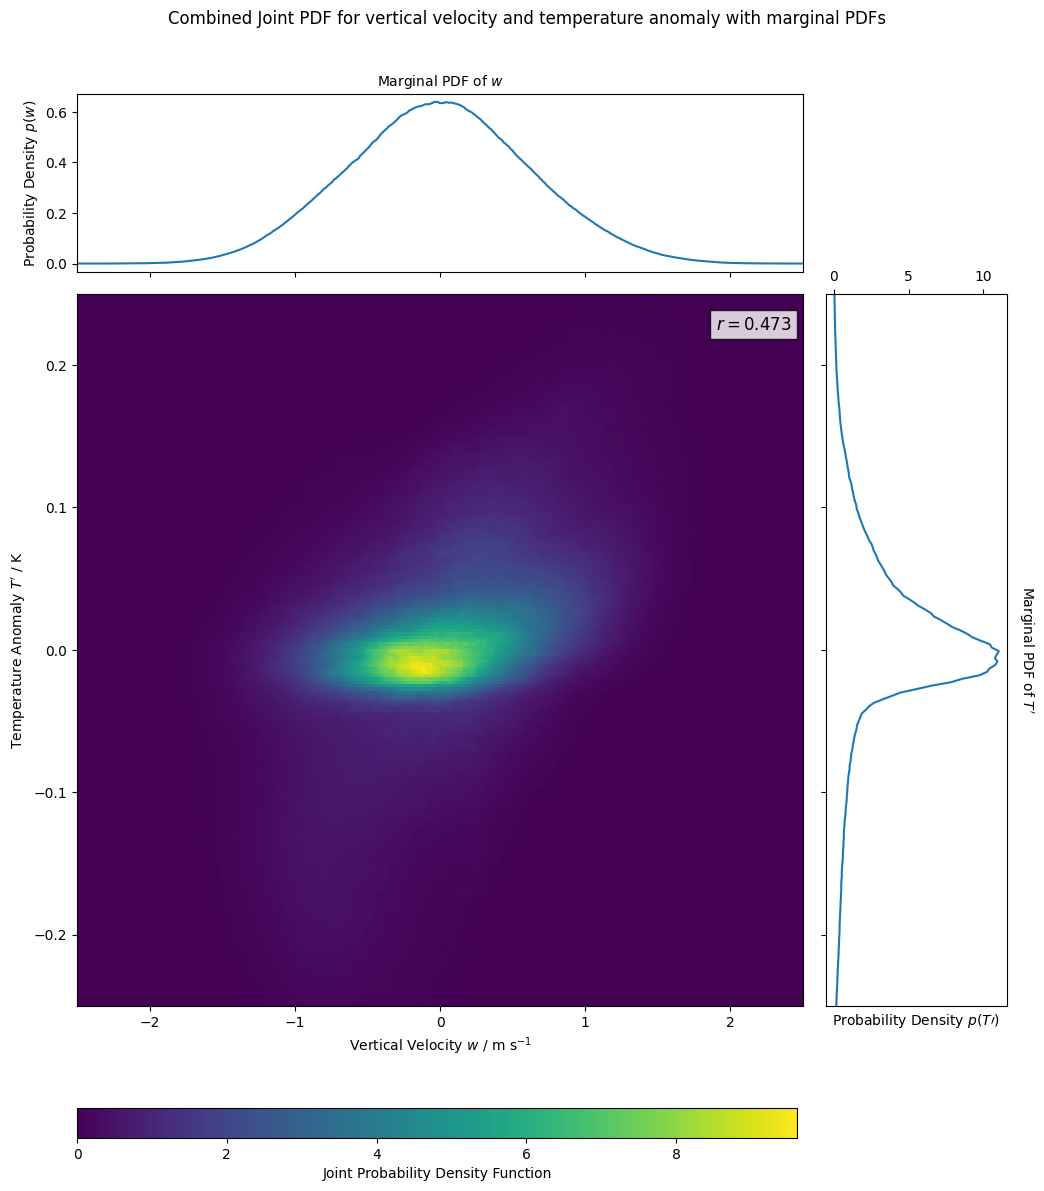

RMS vertical velocity mean: -0.000 m/s
RMS temperature mean: 0.003 K
RMS vertical velocity fluctuation: 0.627 m/s
RMS temperature fluctuation: 0.071 K
Smallest resolved velocity fluctuation: 0.01135 m/s
Smallest resolved temperature fluctuation: 0.00243 K


In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten arrays
w_500 = np.concatenate([vertical_velocity.values.ravel(), vertical_velocity2.values.ravel()])
t_500 = np.concatenate([temp_anom.values.ravel(), temp_anom2.values.ravel()])

# Remove NaNs if present
mask = np.isfinite(w_500) & np.isfinite(t_500)

w_500 = w_500[mask]
t_500 = t_500[mask]

# Pearson correlation coefficient
r = np.corrcoef(w_500, t_500)[0, 1]

# Joint histogram
pdf_500, w500_edges, T500_edges = np.histogram2d(
    w_500,
    t_500,
    bins=500,
    density=True
)

# Marginals
w500_pdf, w500_bins = np.histogram(
    w_500,
    bins=500,
    density=True
)

T500_pdf, T500_bins = np.histogram(
    t_500,
    bins=500,
    density=True
)

# Bin centers
w500_centers = 0.5 * (w500_bins[:-1] + w500_bins[1:])
T500_centers = 0.5 * (T500_bins[:-1] + T500_bins[1:])


# Figure layout
fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[4, 1],
    height_ratios=[1, 4],
    hspace=0.05,
    wspace=0.05
)

ax_joint = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint PDF
pcm = ax_joint.pcolormesh(
    w500_edges,
    T500_edges,
    pdf_500.T,
    shading='auto',
    cmap='viridis'
)

# Correlation coefficient annotation
ax_joint.text(
    0.88,
    0.97,
    rf'$r = {r:.3f}$',
    transform=ax_joint.transAxes,
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        alpha=0.8
    )
)

# Marginals
ax_top.plot(w500_centers, w500_pdf)
ax_right.plot(T500_pdf, T500_centers)

# Labels and limits
ax_joint.set_xlabel(r'Vertical Velocity $w$ / m s$^{-1}$')
ax_joint.set_ylabel(r'Temperature Anomaly $T^\prime$ / K')
ax_joint.set_xlim(-2.5, 2.5)
ax_joint.set_ylim(-0.25, 0.25)

ax_top.set_ylabel(r'Probability Density $p(w)$')
ax_top.set_title(r'Marginal PDF of $w$', fontsize=10)

ax_right.set_xlabel(r'Probability Density $p(T\prime)$')
ax_right.set_ylabel(r'Marginal PDF of $T^\prime$', fontsize=10, rotation=270, labelpad=20)
ax_right.yaxis.set_label_position('right')

# Hide redundant labels
ax_top.tick_params(labelbottom=False)
ax_right.tick_params(labelleft=False, labeltop=True, top=True, bottom=False, labelbottom=False)

# Colorbar
fig.subplots_adjust(bottom=0.12)

# Manual colorbar axis
cax = fig.add_axes([0.125, 0.01, 0.60, 0.025])

# Horizontal colorbar
cbar = fig.colorbar(
    pcm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label('Joint Probability Density Function')

fig.suptitle("Combined Joint PDF for vertical velocity and temperature anomaly with marginal PDFs", y=0.95)

plt.show()


# Means
w_mean = np.mean(w_500)
t_mean = np.mean(t_500)

print(f"RMS vertical velocity mean: {w_mean:.3f} m/s")
print(f"RMS temperature mean: {t_mean:.3f} K")

# RMS fluctuations
w_rms = np.std(w_500)
T_rms = np.std(t_500)

print(f"RMS vertical velocity fluctuation: {w_rms:.3f} m/s")
print(f"RMS temperature fluctuation: {T_rms:.3f} K")

# Smallest resolved fluctuation scales
dw_small = w500_bins[1] - w500_bins[0]
dT_small = T500_bins[1] - T500_bins[0]

print(f"Smallest resolved velocity fluctuation: {dw_small:.5f} m/s")
print(f"Smallest resolved temperature fluctuation: {dT_small:.5f} K")

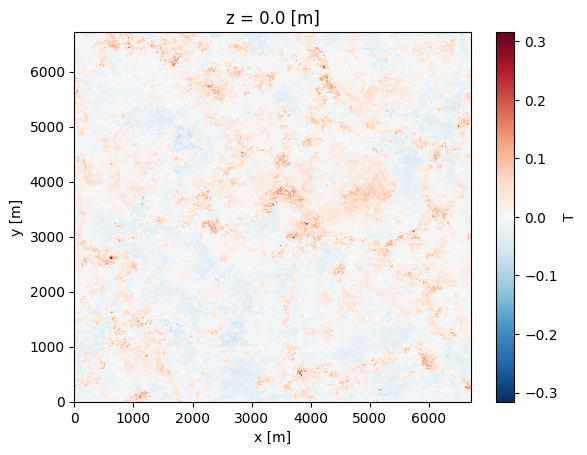

In [20]:
(ds2.T - float(ds2.T.mean(dim=['x', 'y']))).plot()

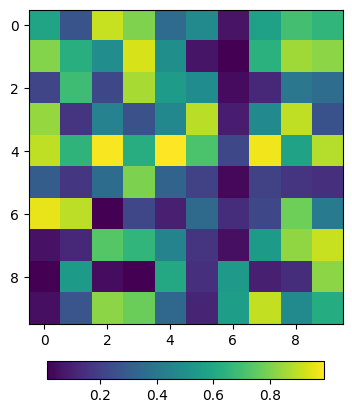

In [46]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
data = np.random.rand(10, 10)
im = ax.imshow(data)

# 'pad' moves it away, 'fraction' shrinks its width, 'aspect' makes it wider
fig.colorbar(im, pad=0.1, fraction=0.05, aspect=15, orientation='horizontal')
plt.show()

In [21]:
temperature = ds2['T'].isel(t=0, z=0)
mean_temp = np.mean(temperature)
mean_temp

<xarray.DataArray 'T' ()> Size: 4B
np.float32(288.49988)
Coordinates:
    z        float32 4B 0.0